In [1]:
import numpy as np
from numpy.polynomial.legendre import leggauss
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Polygon
from mpl_toolkits.mplot3d import Axes3D
import scipy
from scipy.sparse import coo_matrix, csc_matrix
from scipy.sparse.linalg import splu,spsolve
from scipy.linalg import null_space
import meshio
import pygmsh
from numpy.typing import ArrayLike
from scipy.sparse.linalg import eigs
import builtins
import numpy as np
from typing import Callable
import random
from matplotlib.collections import PolyCollection
from matplotlib.tri import Triangulation
import sympy as sp
from numpy.typing import NDArray

_print = builtins.print

def print(*args, **kwargs):
    def colorize(arg):
        if isinstance(arg, (bool, np.bool_)):
            if arg:  # True
                return f'\033[94m{arg}\033[0m'  # Bleu
            else:    # False
                return f'\033[91m{arg}\033[0m'  # Rouge
        return arg
    
    args = [colorize(arg) for arg in args]
    _print(*args, **kwargs)

builtins.print = print

# sys.path.append(r"C:\Users\stordeux\Dropbox\COURS\ANALYSE_NUMERIQUE\ELEMENTS_FINIS\CODE_EF_2D\BIB")
from mes_packages import *

# Construction du maillage


=== Vérification de l'orientation des triangles ===
Nombre total de triangles: 251

Nombre de triangles corrigés: 0/251
Tous les triangles étaient déjà correctement orientés True

=== Vérification de l'orientation des triangles ===
Nombre total de triangles: 251

Nombre de triangles corrigés: 0/251
Tous les triangles étaient déjà correctement orientés True
Aire min : 0.00015160343950614992
Aire max : 0.00035365087391507605
Aires < tol : 0
Tous les triangles ont une aire strictement positive True
Nombre d'éléments : 251
Nombre de sommets : 164


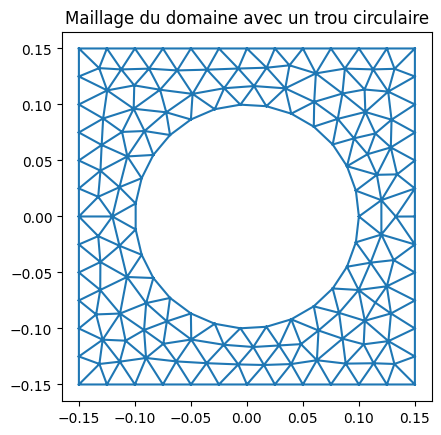

Nombre de triangles : 251
Nombre d'arêtes : 414
Nombre d'arêtes de bord : 75
Table de voisinage correcte True


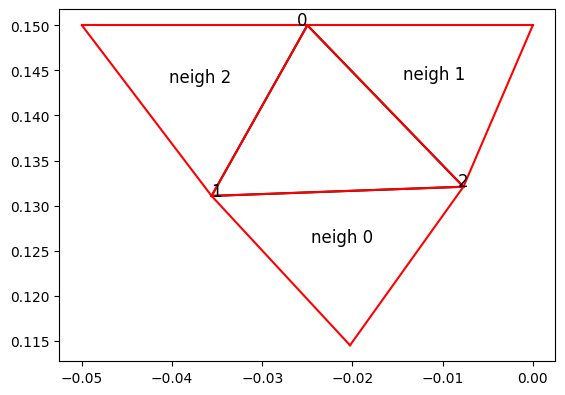

In [2]:
mesh = create_mesh_circle_in_square(radius=0.1, square_size=0.3, mesh_size=0.025)
# Recuperation de la géométrie du maillage
points = mesh.points[:, :2]  # On ne garde que les coordonnées x et y
triangles = np.asarray(mesh.cells_dict["triangle"]) # mesh.cells_dict["triangle"]
nb_corriges = verifier_et_corriger_orientation(mesh)
# Vérification que les triangles ne sont pas dégénrés
areas,bad=check_triangle_areas(points, triangles, tol=1e-12)
if len(bad) == 0:
    print("Tous les triangles ont une aire strictement positive",True)
else:
    print("Tous les triangles ont une aire strictement positive",False)
# Visualisation du maillage
plot_mesh(mesh)

# Construction de la structure de voisinage
neighbors, neighbor_faces, edges_to_triangles = build_neighborhood_structure(triangles)

print(f"Nombre de triangles : {len(triangles)}")
print(f"Nombre d'arêtes : {len(edges_to_triangles)}")

# Compter les arêtes de bord
n_boundary_edges = sum(1 for edge_list in edges_to_triangles.values() if len(edge_list) == 1)
print(f"Nombre d'arêtes de bord : {n_boundary_edges}")
# Test de la table de voisinage
voisinage_reciproque(neighbors,triangles)
plot_un_trianlge_et_ses_voisins(points, triangles, neighbors, iT=np.random.randint(len(triangles)))

# Test du loc to glob 
On affiche ddl par ddl le nombre d'éléments auquel il appartient 

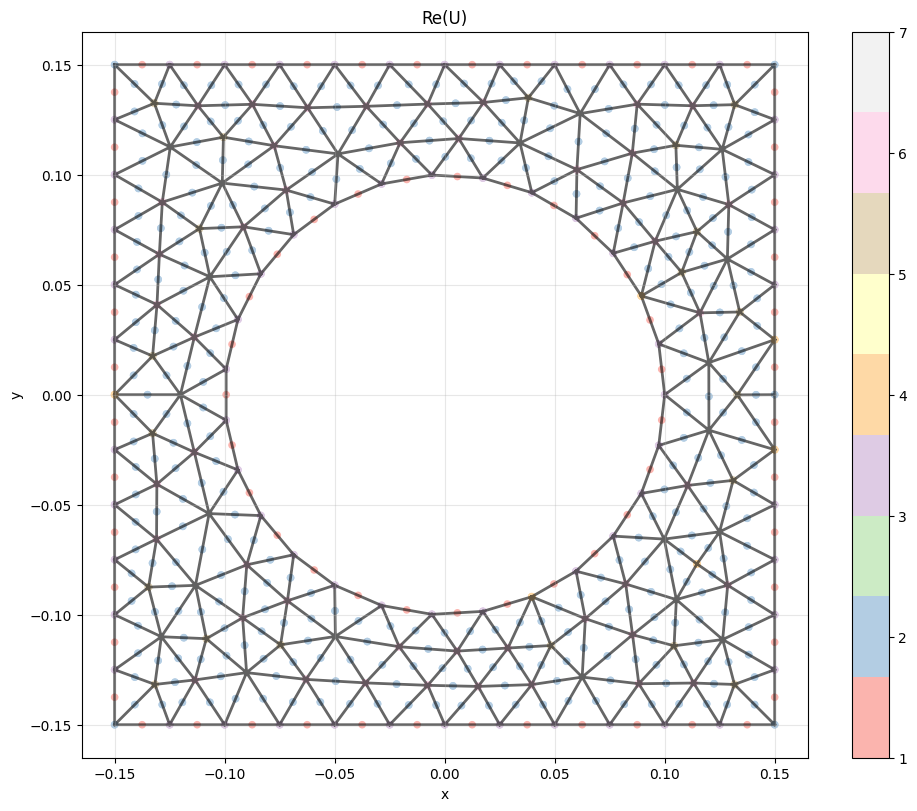

In [3]:
ordre =2
compteur =nombre_DDL_CG_par_DDL_DG(mesh,ordre)

## Assemblage des différentes matrices

In [4]:
MASSE_CG = build_masse_CG(mesh, ordre, verbose=False)

In [5]:
RIGIDITE_CG = build_rigidite_CG(mesh, ordre, verbose=False)

In [6]:
MASSE_BORD_CG = build_masse_frontiere_CG(mesh, ordre) 

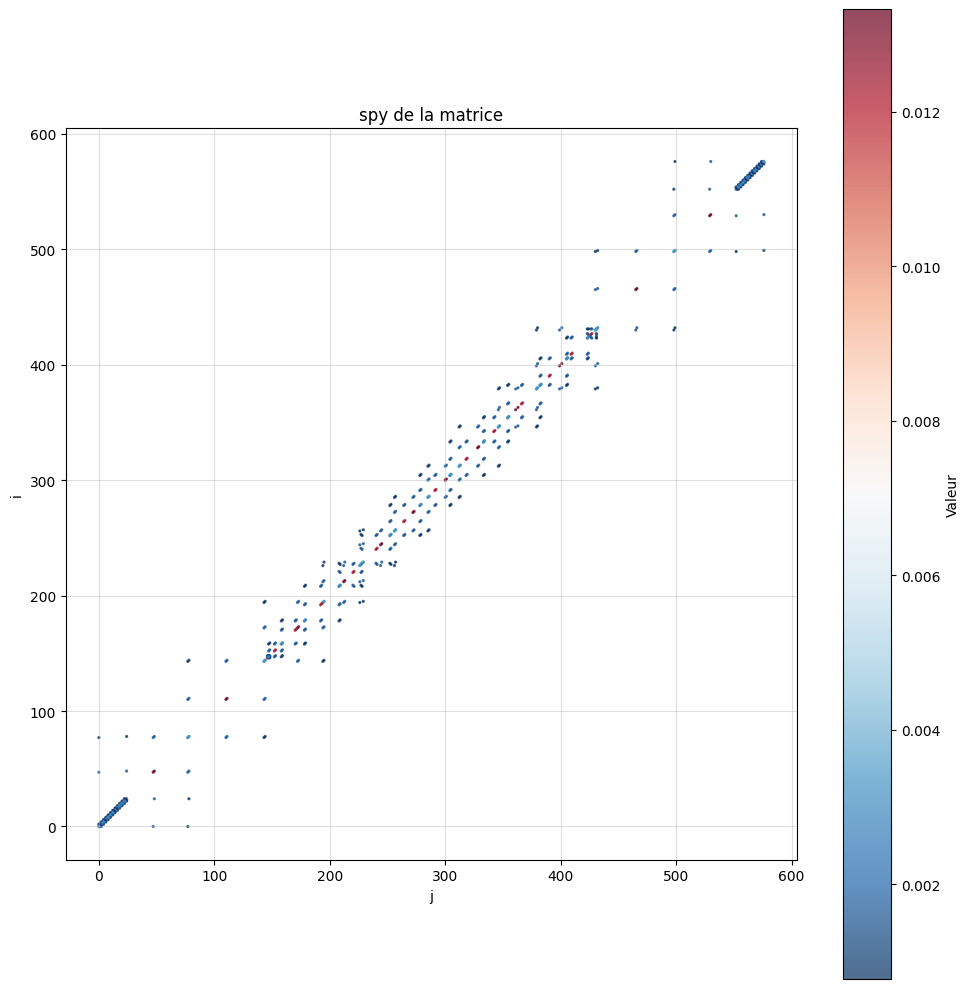

(<Figure size 1000x1000 with 2 Axes>,
 <Axes: title={'center': 'spy de la matrice'}, xlabel='j', ylabel='i'>)

In [7]:
MASSE_BORD_CG.spy()

In [8]:
# Résolution du problème de Fourier sur les frontières intérieures et extérieures
lambda_waves = 0.1
kappa = 2 * np.pi / lambda_waves
alpha = 1j * kappa
# Création de la matrice globale C0
taille_MAT = nombre_dof_CG(mesh, ordre)
Nnz = RIGIDITE_CG.nnz + MASSE_CG.nnz + MASSE_BORD_CG.nnz
MAT_EF_CG = COOMatrix(taille_MAT, taille_MAT, Nnz)
# Assemblage des matrices de masse et rigidité dans la matrice globale
MAT_EF_CG = MAT_EF_CG + RIGIDITE_CG
kappa2_MASSE_CG = kappa**2 * MASSE_CG
MAT_EF_CG =MAT_EF_CG - kappa2_MASSE_CG
ik_MASSE_BORD_CG = alpha * MASSE_BORD_CG
MAT_EF_CG = MAT_EF_CG + ik_MASSE_BORD_CG
# Construction du terme source 
# f(x,y) = exp(ikx) sur la frontière en symbolique

# Création du second membre

In [9]:
x, y = sp.symbols('x y')
f_source_sym = sp.exp(1j * kappa * x)


In [10]:

f_source, dfx_source, dfy_source = build_f_and_grads(f_source_sym, (x, y))
F_CG = termes_source_frontiere_CG(f_source,mesh, ordre)
dn_F_CG = termes_source_frontiere_gradn_CG(dfx_source, dfy_source, mesh, ordre)

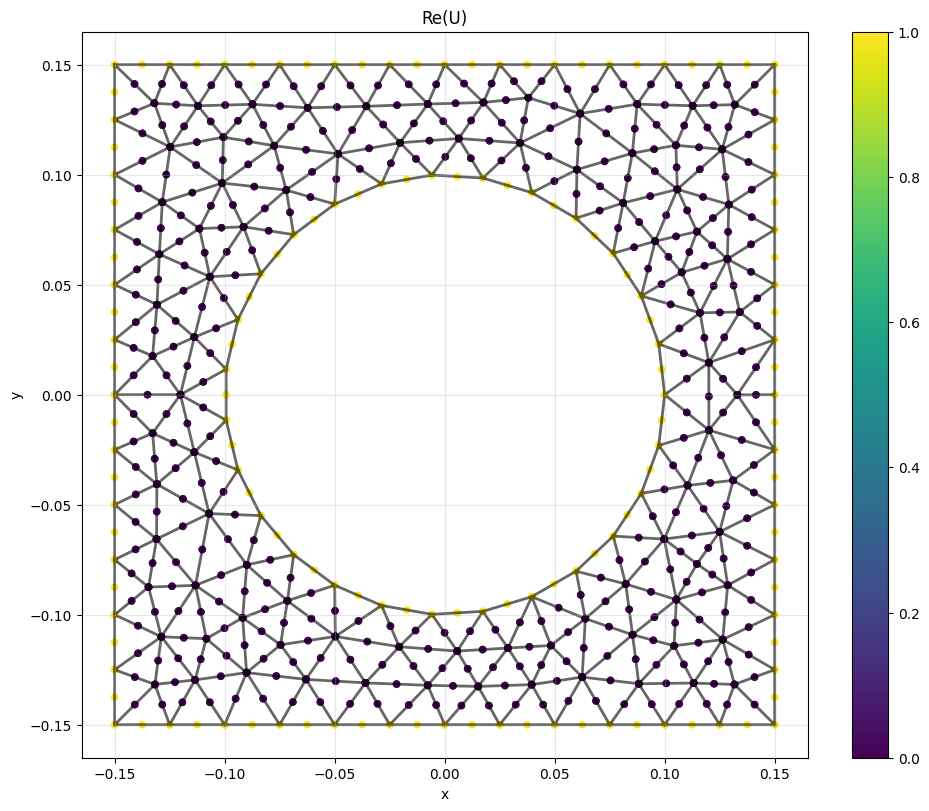

In [11]:
plot_support_terme_source(F_CG, mesh, ordre)

# Résolution

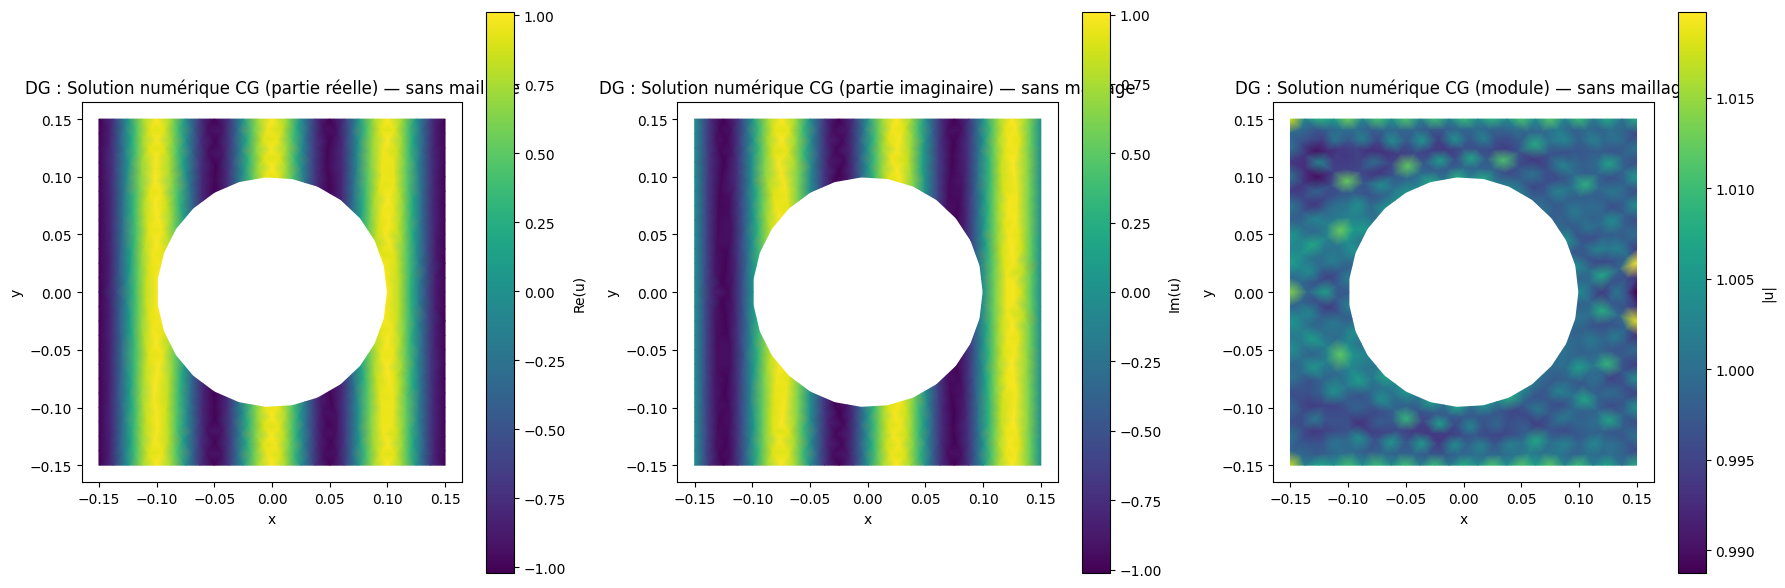

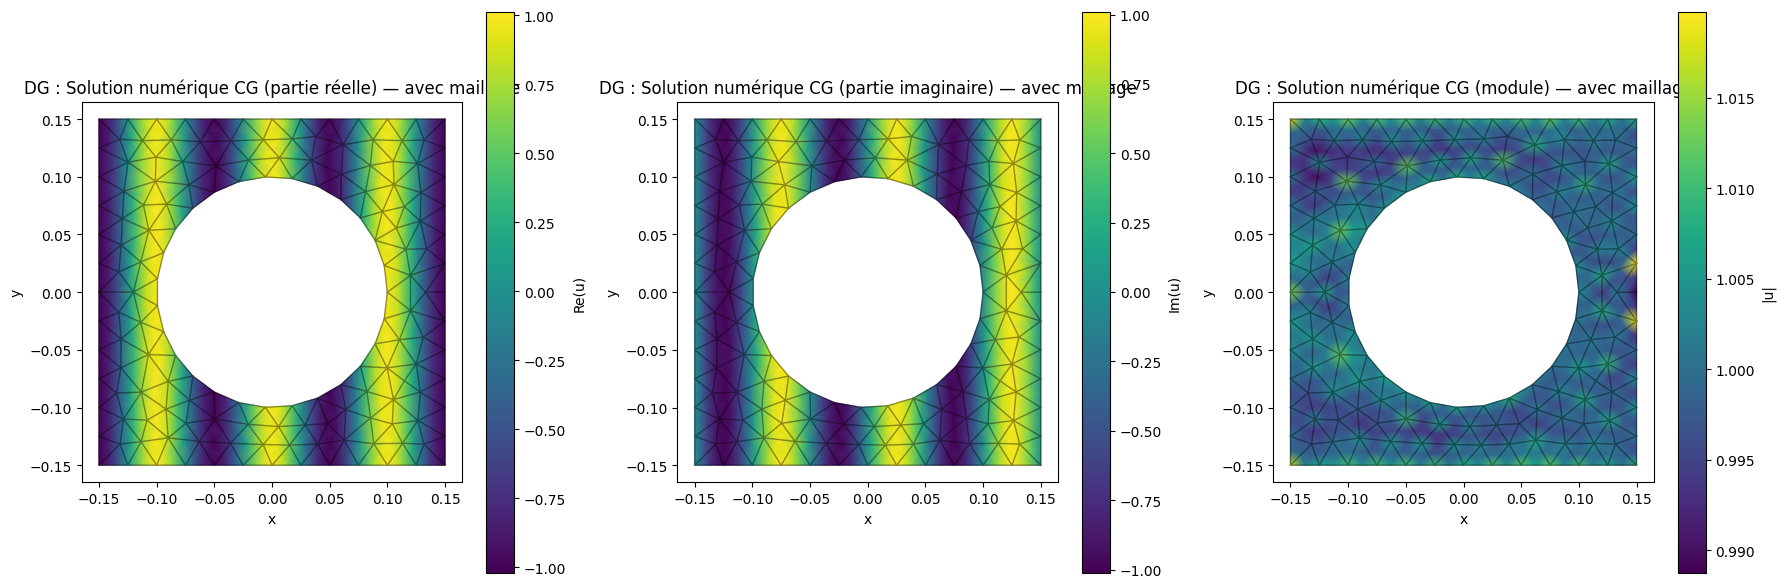

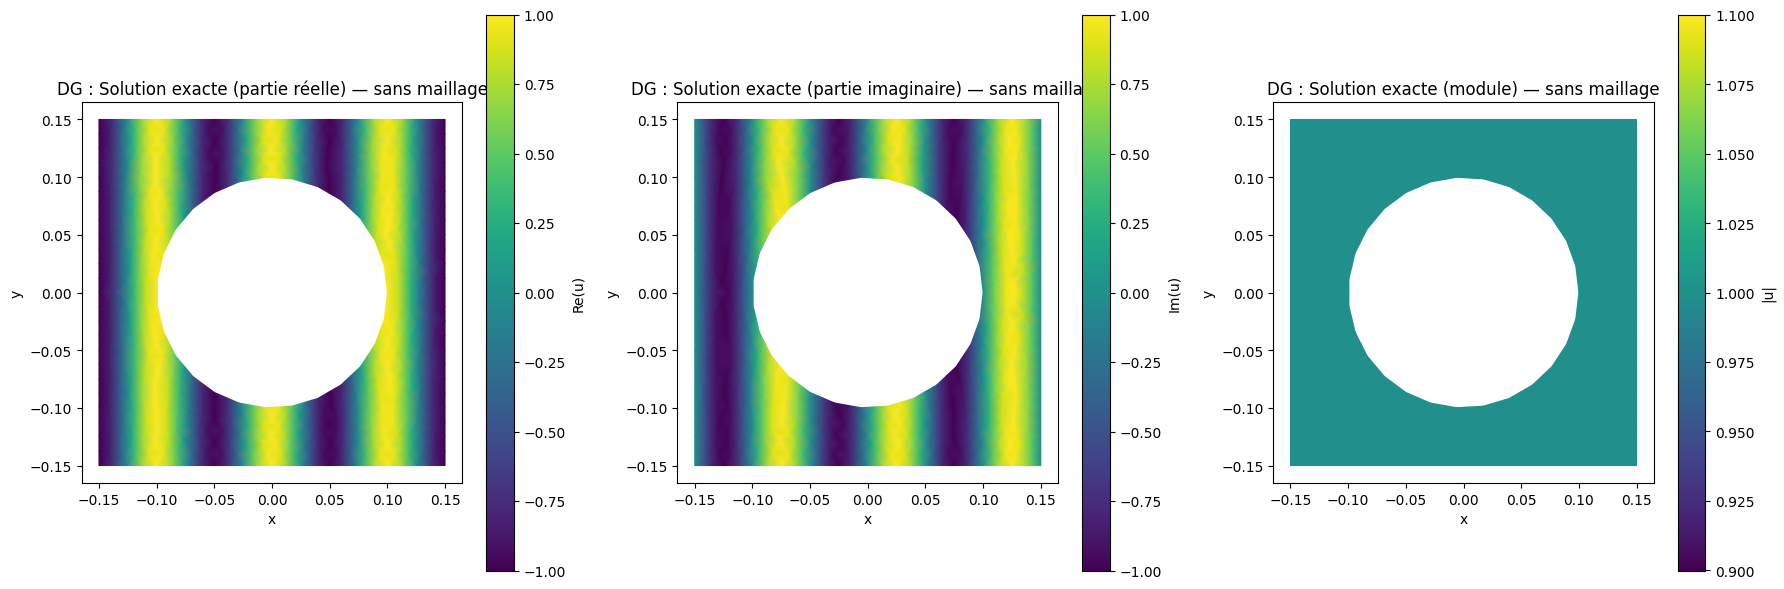

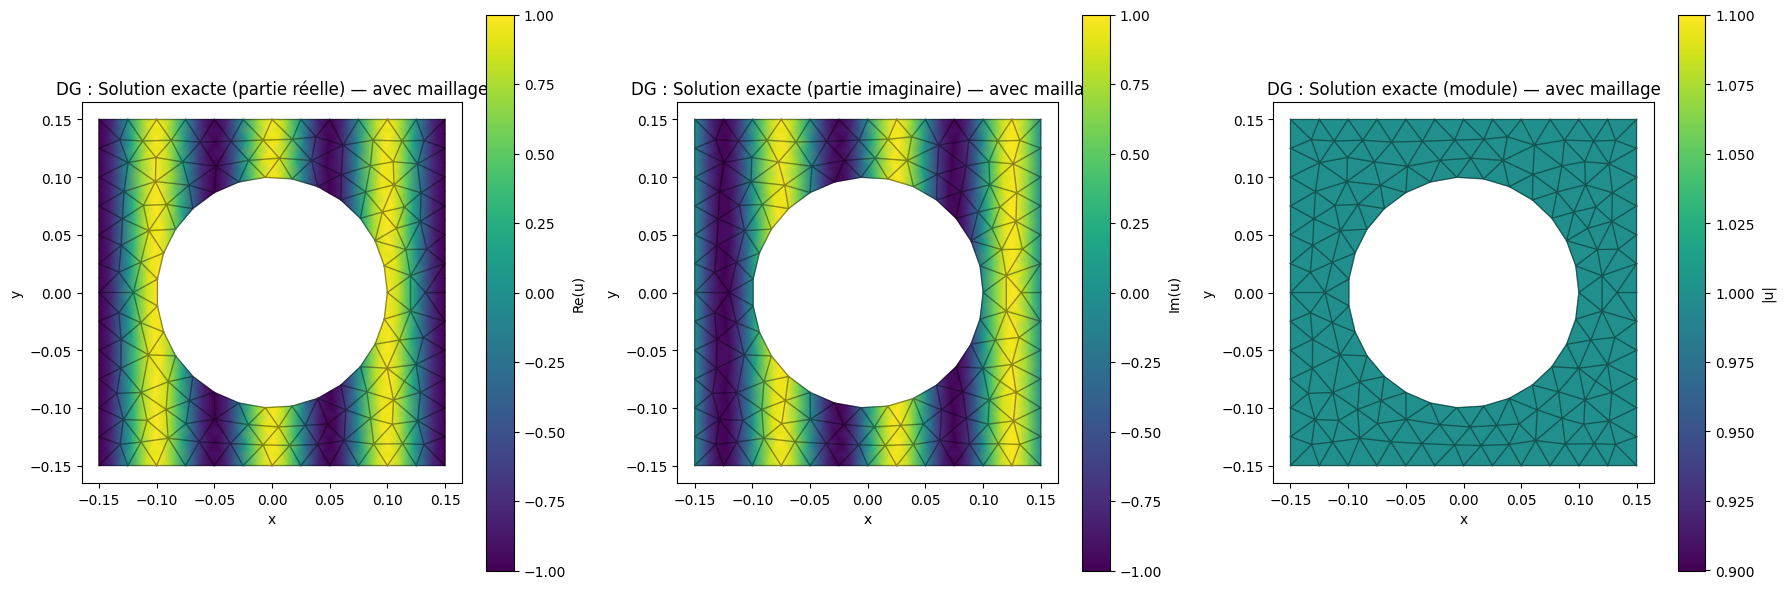

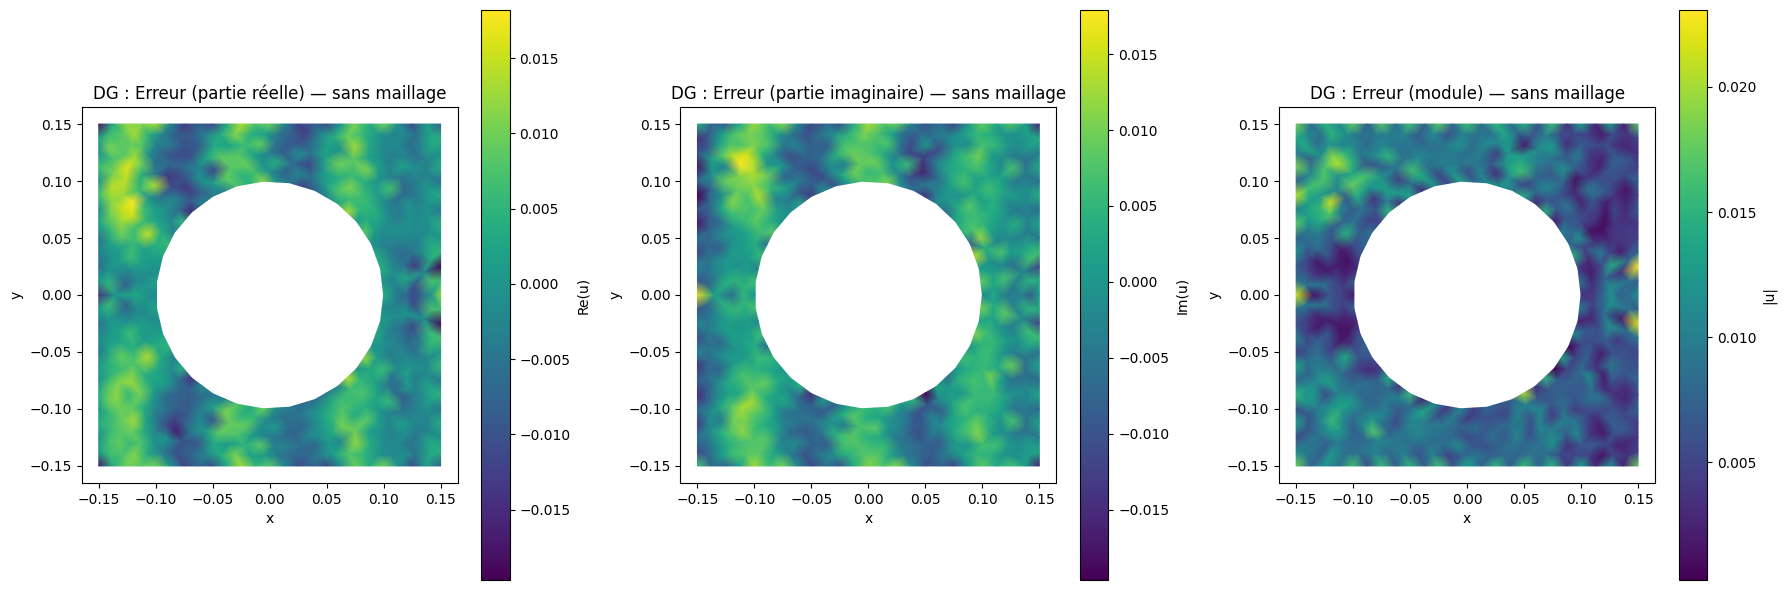

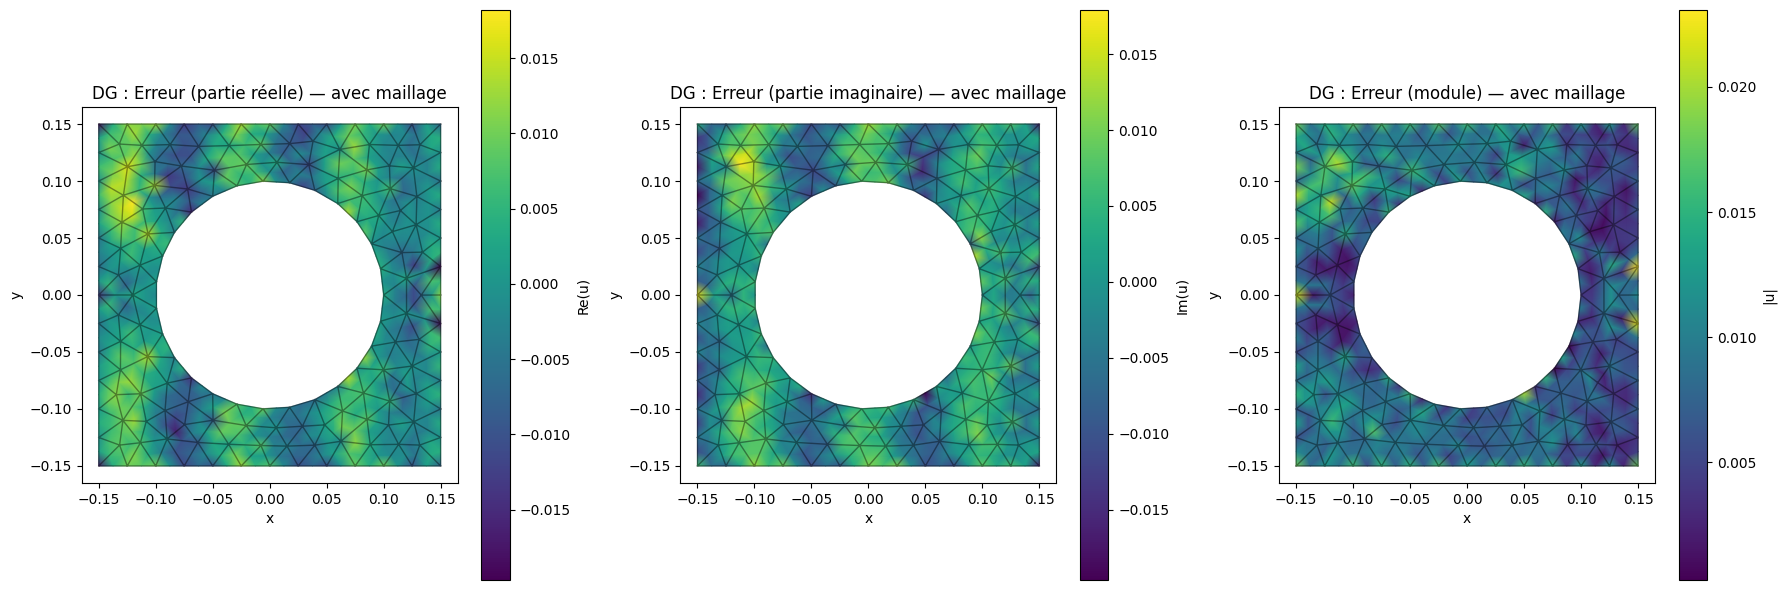

In [12]:
# Conversion de la matrice en format compressé pour la résolution
MAT_EF_CG.create_COO()  # Crée la matrice scipy COO si ce n'est pas déjà fait
MAT_EF_CG.to_csc()      # Conversion en format CSC (Compressed Sparse Column)




# Résolution du système linéaire K_CG * U_sol = F_CG
U_sol = spsolve(MAT_EF_CG.csc, dn_F_CG+alpha*F_CG)

# Visualisation du résultat
plot_nodal_vector_CG(U_sol, mesh, ordre, "Solution numérique CG")


U_ex = build_nodal_vector_CG(f_source,mesh,ordre)
plot_nodal_vector_CG(U_ex, mesh, ordre, "Solution exacte")

# Représentation de l'erreur
U_err = U_sol - U_ex
plot_nodal_vector_CG(U_err, mesh, ordre, "Erreur")

## Assemblage de la matrice de rigidité (C0)

La **matrice de rigidité** $K_{C0}$ correspond à la discrétisation du Laplacien (ou opérateur de diffusion) en éléments finis continus. Elle est définie par :

$$
K_{i,j} = \int_\Omega \nabla \varphi_i \cdot \nabla \varphi_j \, dx
$$

où $\varphi_i$, $\varphi_j$ sont les fonctions de base globales associées aux degrés de liberté (DDL) du maillage.

### Étapes de l’assemblage

1. **Boucle sur les triangles** :  
   Pour chaque triangle $T$ du maillage, on calcule la matrice de rigidité locale $K^{(T)}$.

2. **Calcul de la matrice locale** :  
   $K^{(T)}$ est obtenue par transformation du triangle de référence vers le triangle réel, en tenant compte du jacobien et des dérivées des fonctions de base.

3. **Boucle sur les DDL locaux** :  
   Pour chaque couple de DDL locaux $(i_{loc}, j_{loc})$ du triangle $T$ :
   - On convertit les indices locaux en indices globaux via la table `loc_to_glob_CG`.
   - On ajoute la contribution locale à la matrice globale :
     $$
     K_{C0}[i_{glob}, j_{glob}] \mathrel{+}= K^{(T)}[i_{loc}, j_{loc}]
     $$
   - Si un DDL est partagé par plusieurs triangles, les contributions sont sommées automatiquement.


# Assemblage des matrices dans la numérotation continue

# Assemblage des matrices dans la numérotation continue

## Principe de l'assemblage en méthode C0

En **méthode C0** (Galerkin continue), contrairement à la méthode DG, les degrés de liberté (DDL) sont **partagés entre triangles adjacents**. Cela signifie qu'un même DDL physique (situé sur une arête ou un sommet commun) appartient à plusieurs triangles.

### Différence DG vs C0

| Méthode | DDL par triangle | DDL globaux | Assemblage |
|---------|------------------|-------------|------------|
| **DG** | $N_{loc}$ privés | $N_{glob} = N_T \times N_{loc}$ | Chaque élément indépendant |
| **C0** | $N_{loc}$ partagés | $N_{glob} \ll N_T \times N_{loc}$ | Accumulation des contributions |

### Structure de `loc_to_glob_CG`

La table `loc_to_glob_CG[iT, iloc1, iloc2]` donne l'indice global du DDL local $(iloc1, iloc2)$ du triangle $iT$ :

$$
\text{loc\_to\_glob\_CG}[i_T, i_{loc1}, i_{loc2}] = i_{glob} \in \{0, \ldots, N_{glob}^{C0} - 1\}
$$

**Propriété clé** : Si deux triangles $T$ et $T'$ partagent un DDL à la même position $(x,y)$, alors :
$$
\text{loc\_to\_glob\_CG}[T, i_{loc1}, i_{loc2}] = \text{loc\_to\_glob\_CG}[T', i'_{loc1}, i'_{loc2}]
$$

### Assemblage des matrices en C0

Pour construire la matrice globale $\mathbf{M}^{C0}$, on suit le processus :

1. **Calcul des matrices locales** : Pour chaque triangle $T$, calculer $\mathbf{M}^{(T)}_{loc}$

2. **Parcours des DDL locaux** : Pour chaque couple de DDL locaux $(i_{loc}, j_{loc})$ du triangle $T$ :
   - Convertir $(m_1, n_1) \rightarrow i_{loc}$ et $(m_2, n_2) \rightarrow j_{loc}$ via `loc2D_to_loc1D`
   - Récupérer les indices globaux :
     $$
     i_{glob} = \text{loc\_to\_glob\_CG}[T, m_1, n_1]
     $$
     $$
     j_{glob} = \text{loc\_to\_glob\_CG}[T, m_2, n_2]
     $$

3. **Accumulation** : Ajouter la contribution locale à la matrice globale :
   $$
   M^{C0}_{i_{glob}, j_{glob}} \mathrel{+}= M^{(T)}_{i_{loc}, j_{loc}}
   $$

Le même couple $(i_{glob}, j_{glob})$ peut recevoir des contributions de plusieurs triangles (ceux qui partagent ces DDL). L'opérateur `+=` est essentiel.


# Assemblage du terme source

Dans la formulation variationnelle d’un problème aux éléments finis, le **terme source** correspond à l’intégrale du second membre (ou forçage) contre les fonctions de base :

$$
F_i = \int_{\partial\Omega} f(x, y) \, \varphi_i(x, y) \, ds_{x,y}
$$

où $f(x, y)$ est la fonction source (donnée du problème) et $\varphi_i$ la fonction de base associée au DDL $i$.

# Assemblage du second terme source

Dans la formulation variationnelle d’un problème aux éléments finis, le **terme source** correspond à l’intégrale du second membre (ou forçage) contre les fonctions de base :

$$
F_i = \int_{\partial \Omega} \nabla f(x, y)\cdot n(x,y) \, \varphi_i(x, y) \, ds_{x,dy}
$$

où $f(x, y)$ est la fonction source (donnée du problème) et $\varphi_i$ la fonction de base associée au DDL $i$.



## Création du loc_to_glob

### Objectif

Construire la table de correspondance **locale → globale** pour une numérotation **C0** (continue), où les degrés de liberté sont partagés entre triangles adjacents.

### Différence DG vs C0

- **DG (Galerkin Discontinu)** : Chaque triangle a ses propres DDL
  - `iglob_DG = Nloc * iT + iloc`
  - Pas de partage entre éléments
  
- **C0 (Continu)** : Les DDL sur les arêtes/sommets communs sont partagés
  - Un même point physique $(x,y)$ a le même `iglob` dans tous les triangles qui le contiennent
  - `loc_to_glob[iT, iloc1, iloc2] = iglob`

### Algorithme

1. **Calcul des coordonnées** : Pour chaque DDL de chaque triangle, calculer sa position $(x,y)$

2. **Tri lexicographique** : Trier tous les points par $(x, y)$ pour regrouper les points identiques

3. **Fusion des points proches** : Parcourir la liste triée et attribuer le même `iglob` aux points dont la distance est < 1e-6

4. **Construction de la table** : Remplir `loc_to_glob[iT, iloc1, iloc2]` avec l'indice global C0 correspondant


# Exemple d'utilisation

- `loc_to_glob[iT, iloc1, iloc2]` : indice global C0 du DDL local $(iloc1, iloc2)$ du triangle $iT$
- `glob_to_xy[iglob]` : coordonnées $(x,y)$ du DDL global C0 d'indice `iglob`
- `Nglob_CG` << `Nglob_DG` : gain important en nombre de DDL


In [13]:

loc_to_glob_CG, glob_to_xy_CG, Nglob_CG=build_loctoglob_CG(mesh, ordre)